In [58]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("8-fraud_detection.csv")

In [3]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [4]:
df.columns

Index(['transaction_amount', 'transaction_risk_score', 'is_fraud'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_amount      10000 non-null  float64
 1   transaction_risk_score  10000 non-null  float64
 2   is_fraud                10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [6]:
df.describe()

,transaction_amount,transaction_risk_score,is_fraud
count,10000.000000,10000.000000,10000.000000
mean,0.976419,-1.003136,0.015400
std,0.725346,0.789194,0.123144
min,-3.370100,-3.952121,0.000000
25%,0.505517,-1.538232,0.000000
50%,0.990240,-0.997064,0.000000
75%,1.461125,-0.466221,0.000000
max,3.487193,1.872543,1.000000


In [7]:
df["is_fraud"].unique()

array([0, 1])

In [8]:
df["is_fraud"].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [9]:
# yukarıdaki data setimiz inbalance dataset oluyor  hiç bir baglantısı yok unique degerler arasında 

In [10]:
# burada 1 sayısını azaltıp yazda sıfırın sayısını arttırmamız lazım

In [11]:
df.isnull().sum()

transaction_amount        0
transaction_risk_score    0
is_fraud                  0
dtype: int64

In [12]:
X = df.drop("is_fraud",axis=1)
y = df["is_fraud"]

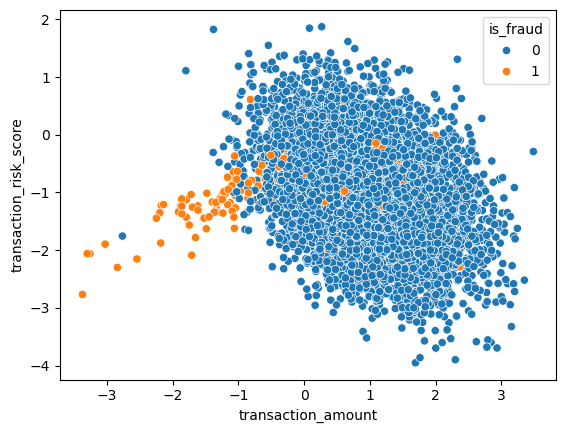

In [13]:
sns.scatterplot(x=X["transaction_amount"],y=X["transaction_risk_score"],hue=y)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [17]:
penalty = ["l1","l2","elasticnet"]
c_values = [100,10,1.0,0.1,0.0]
solver = ["newton-cg","lbfgs","liblinear","sag","sage","newton-cholesky"]
class_weight = [{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [18]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [19]:
# ==============================================================================================
# --- CLASS WEIGHT (Sınıf Ağırlığı) NEDİR? ---
# Mantık: Veri setindeki dengesizliği (bir sınıfın az, diğerinin çok olması durumunu) çözmek için 
# az olan sınıfa daha fazla önem/ağırlık verilmesini sağlayan parametredir.
# ==============================================================================================

# ==============================================================================================
# --- NEREDE VE NASIL KULLANILIR? ---
# Nerede: Dolandırıcılık tespiti (1000 işlemden 1'i sahte) veya nadir hastalık teşhisi gibi 
# hedef değişkenin (y) sınıflarının eşit dağılmadığı durumlarda (Imbalanced Data) kullanılır.
#
# Nasıl: 
# 1. Otomatik Çözüm: Modeli kurarken `class_weight='balanced'` yazılarak kütüphaneye otomatik hesaplatılır.
# 2. Manuel Çözüm (Görseldeki gibi): Az bulunan sınıfa elle yüksek ceza puanı/ağırlık atanır (Örn: {0: 1, 1: 100}).
# ==============================================================================================

In [33]:
params = dict(penalty=penalty,C=c_values,solver=solver,class_weight = class_weight)

In [34]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [35]:
cv = StratifiedKFold()

In [36]:
grid = GridSearchCV(estimator= model , param_grid=params,scoring="accuracy",cv=cv)

In [37]:
import warnings
warnings.filterwarnings("ignore")

In [38]:
grid.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.0],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'sage', 'newton-cholesky']},
             scoring='accuracy')

In [39]:
y_pred = grid.predict(X_test)

In [40]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [41]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [42]:
print("score:",accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))
print("confusion metrix: \n",confusion_matrix(y_pred,y_test))

score: 0.9896
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2480
           1       0.42      0.80      0.55        20

    accuracy                           0.99      2500
   macro avg       0.71      0.90      0.77      2500
weighted avg       0.99      0.99      0.99      2500

confusion metrix: 
 [[2458   22]
 [   4   16]]


In [43]:
grid.best_params_

{'C': 100,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [44]:
grid.best_score_

np.float64(0.9881333333333334)

In [45]:
# ROC AND AUC 

In [46]:
# ROC Eğrisi ve AUC, sınıflandırma modellerinin başarısını sınıf dağılımı ve eşik değerlerinden bağımsız olarak ölçen araçlardır.
# ROC eğrisi tüm eşiklerdeki doğru/yanlış pozitif oranlarını grafikleştirirken, AUC değeri bu eğrinin altında kalan alanı (1 mükemmel, 0.5 rastgele) ifade eder.

In [47]:
model_prob = grid.predict_proba(X_test)

In [48]:
model_prob

array([[0.99648758, 0.00351242],
       [0.85196996, 0.14803004],
       [0.95448477, 0.04551523],
       ...,
       [0.99034239, 0.00965761],
       [0.98582985, 0.01417015],
       [0.99795071, 0.00204929]])

In [49]:
model_prob = model_prob[:,1]

In [51]:
model_prob # sadece pozitif kısmı görmek için böyle yaptık

array([0.00351242, 0.14803004, 0.04551523, ..., 0.00965761, 0.01417015,
       0.00204929])

In [52]:
from sklearn.metrics import roc_auc_score,roc_curve

In [53]:
model_suc = roc_auc_score(y_test,model_prob)

In [54]:
model_suc

np.float64(0.7380499380050451)

In [55]:
# model false positive rate
# model true positive rate 
model_fpr,model_tpr,thresholds = roc_curve(y_test,model_prob)

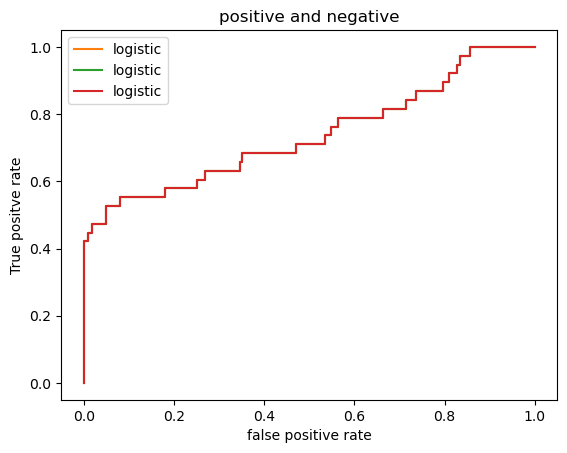

In [60]:
plt.plot(model_fpr,model_tpr,marker = ",",label="logistic")
plt.xlabel("false positive rate")
plt.ylabel("True positve rate")
plt.title("positive and negative")
plt.legend()
plt.show()

In [61]:
# folse positive rate bizm için çok iyi bir şey degil bizim için en iyi olan şey true pozite rate tablomuz ne kadar dik giderse o kadar iyi olur bizim için

In [62]:
# bu tabloyu inbalance verilerinde çizdirmek çok önemlidir inbalance verilerinde bunu kullan

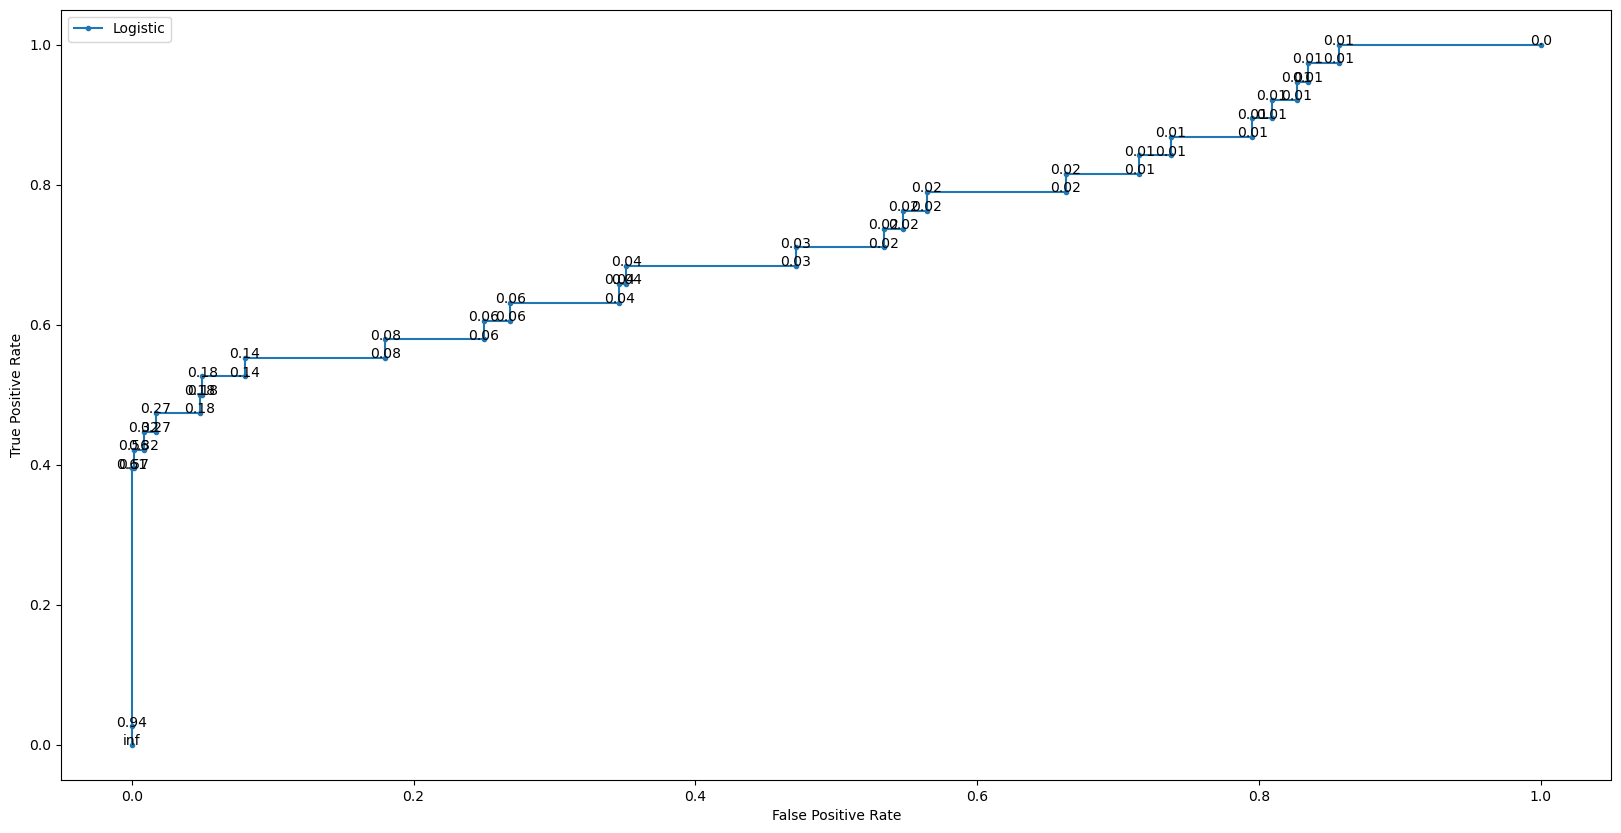

In [63]:
fig, ax = plt.subplots(figsize = (20,10))

ax.plot(model_fpr, model_tpr, marker = ".", label = "Logistic")

for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f"{np.round(thresh, 2)}", (fpr, tpr), ha="center")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

In [64]:
# ÖZET: Lojistik Regresyon modelinin ROC Eğrisini çizer. 
# Grafikteki her noktanın üzerine ilgili eşik değerini (threshold) yazarak, 
# modeli optimize etmek için en ideal sınıflandırma eşiğini seçmene yardımcı olur.


In [65]:
# modellimz böyle dikine başlıyorsa iyidir
